In [ ]:
!pip install xgboost shap scikit-learn pandas numpy matplotlib -q


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import xgboost as xgb
import shap
import matplotlib.pyplot as plt


In [ ]:
!ls

'Corporate Default Prediction.csv'   sample_data


In [ ]:
print(df['Label'].unique())
print(df['Label'].dtype)

['1' nan 'Label' '0']
object


In [ ]:
df = df.dropna(subset=['Label'])
df = df[df['Label'].isin([0, 1])]
df['Label'] = df['Label'].astype(int)

In [ ]:
df = pd.read_csv('Corporate Default Prediction.csv')

df = df.rename(columns={
    'Debt/Equity': 'Debt_Equity',
    'Interest Coverage': 'Interest_Coverage',
    'Operating Margin': 'Operating_Margin',
    'Sales Growth': 'Sales_Growth',
    'OCF / Total Debt': 'OCF_Debt'
})

# Force ALL feature columns to numeric, stripping any % signs or stray text
features = ['Debt_Equity','Interest_Coverage','ROA','ROE','Operating_Margin','Sales_Growth','OCF_Debt']
for col in features:
    df[col] = df[col].astype(str).str.replace('%','').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean up the Label column
df['Label'] = pd.to_numeric(df['Label'], errors='coerce')
df = df.dropna(subset=['Label'])
df = df[df['Label'].isin([0, 1])]
df['Label'] = df['Label'].astype(int)

X = df[features].values
y = df['Label'].values
companies = df['Company'].values

print(f"Dataset: {len(df)} companies ({int(y.sum())} distressed, {int(len(y)-y.sum())} stable)")
print(df[features].dtypes)
print("\nMissing values per column:")
print(df[features].isna().sum())

Dataset: 40 companies (20 distressed, 20 stable)
Debt_Equity          float64
Interest_Coverage    float64
ROA                  float64
ROE                  float64
Operating_Margin     float64
Sales_Growth         float64
OCF_Debt             float64
dtype: object

Missing values per column:
Debt_Equity          0
Interest_Coverage    0
ROA                  0
ROE                  0
Operating_Margin     0
Sales_Growth         0
OCF_Debt             0
dtype: int64


In [ ]:
df_lr = df.copy()
df_lr['Debt_Equity'] = df_lr['Debt_Equity'].fillna(df_lr[df_lr['Label']==0]['Debt_Equity'].median())
df_lr['Operating_Margin'] = df_lr['Operating_Margin'].fillna(df_lr[df_lr['Label']==1]['Operating_Margin'].median())
df_lr['Sales_Growth'] = df_lr['Sales_Growth'].fillna(df_lr['Sales_Growth'].median())
df_lr['OCF_Debt'] = df_lr['OCF_Debt'].fillna(df_lr[df_lr['Label']==0]['OCF_Debt'].median())

X_lr = df_lr[features].values

loo = LeaveOneOut()
lr_preds, lr_probs = [], []
for train_idx, test_idx in loo.split(X_lr):
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_lr[train_idx])
    X_test = scaler.transform(X_lr[test_idx])
    lr = LogisticRegression(max_iter=1000, C=0.5)
    lr.fit(X_train, y[train_idx])
    lr_preds.append(lr.predict(X_test)[0])
    lr_probs.append(lr.predict_proba(X_test)[0][1])

print("=== Logistic Regression (LOOCV) ===")
print(f"Accuracy: {accuracy_score(y, lr_preds):.3f}")
print(f"ROC-AUC: {roc_auc_score(y, lr_probs):.3f}")
print("Confusion Matrix:\n", confusion_matrix(y, lr_preds))

print("=== Logistic Regression (LOOCV) ===")
print(f"Accuracy: {accuracy_score(y, lr_preds):.3f}")
print(f"ROC-AUC: {roc_auc_score(y, lr_probs):.3f}")
print("Confusion Matrix:\n", confusion_matrix(y, lr_preds))

=== Logistic Regression (LOOCV) ===
Accuracy: 0.775
ROC-AUC: 0.850
Confusion Matrix:
 [[15  5]
 [ 4 16]]
=== Logistic Regression (LOOCV) ===
Accuracy: 0.775
ROC-AUC: 0.850
Confusion Matrix:
 [[15  5]
 [ 4 16]]


In [ ]:
xgb_preds, xgb_probs = [], []
for train_idx, test_idx in loo.split(X):
    model = xgb.XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.1,
                               reg_lambda=5, reg_alpha=1, subsample=0.8, eval_metric='logloss')
    model.fit(X[train_idx], y[train_idx])
    xgb_preds.append(model.predict(X[test_idx])[0])
    xgb_probs.append(model.predict_proba(X[test_idx])[0][1])

print("=== XGBoost (LOOCV) ===")
print(f"Accuracy: {accuracy_score(y, xgb_preds):.3f}")
print(f"ROC-AUC: {roc_auc_score(y, xgb_probs):.3f}")
print("Confusion Matrix:\n", confusion_matrix(y, xgb_preds))

=== XGBoost (LOOCV) ===
Accuracy: 0.750
ROC-AUC: 0.792
Confusion Matrix:
 [[14  6]
 [ 4 16]]


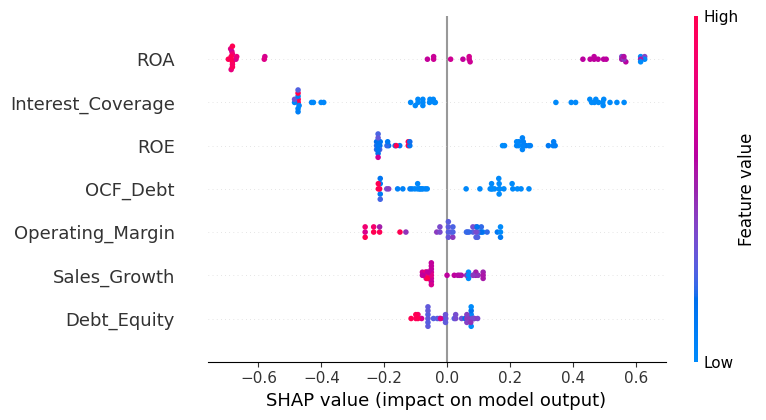

In [ ]:
model_full = xgb.XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.1,
                                 reg_lambda=5, reg_alpha=1, subsample=0.8, eval_metric='logloss')
model_full.fit(df[features], y)
explainer = shap.TreeExplainer(model_full)
shap_values = explainer.shap_values(df[features])

shap.summary_plot(shap_values, df[features], show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

In [ ]:
print("=== Misclassified Companies (XGBoost) ===")
for i, (pred, true, comp) in enumerate(zip(xgb_preds, y, companies)):
    if pred != true:
        print(f"{comp}: True={true}, Predicted={pred}, Probability={xgb_probs[i]:.3f}")

=== Misclassified Companies (XGBoost) ===
Cox & Kings: True=1, Predicted=0, Probability=0.428
Gitanjali Gems: True=1, Predicted=0, Probability=0.191
Era Infra Engineering: True=1, Predicted=0, Probability=0.436
Talwalkars Better Value Fitness Ltd: True=1, Predicted=0, Probability=0.186
Thomas Cook India: True=0, Predicted=1, Probability=0.741
IndusInd Bank: True=0, Predicted=1, Probability=0.653
Bharti Airtel: True=0, Predicted=1, Probability=0.811
Thangamayil Jewellery Ltd.: True=0, Predicted=1, Probability=0.525
NCC Ltd: True=0, Predicted=1, Probability=0.835
Can Fin Homes: True=0, Predicted=1, Probability=0.510


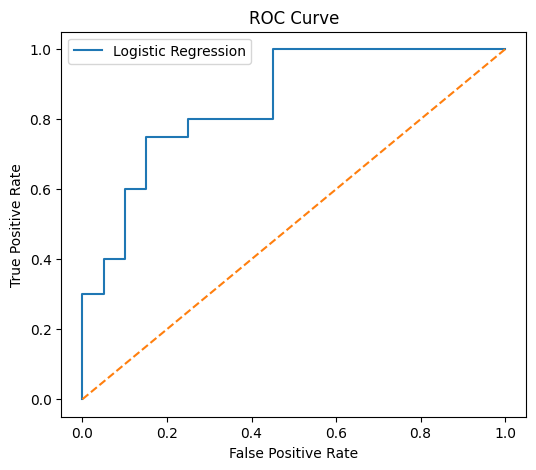

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y, lr_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label='Logistic Regression')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

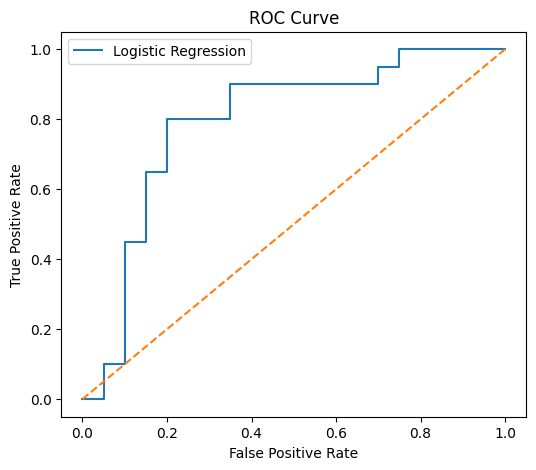

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y, xgb_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label='Logistic Regression')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

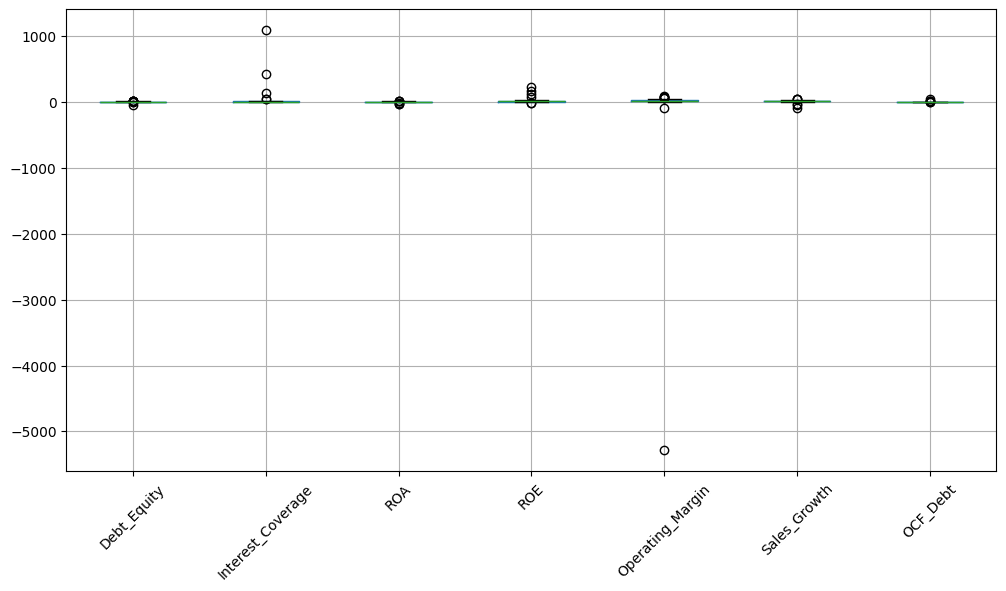

In [ ]:
import matplotlib.pyplot as plt

df.boxplot(column=features, figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

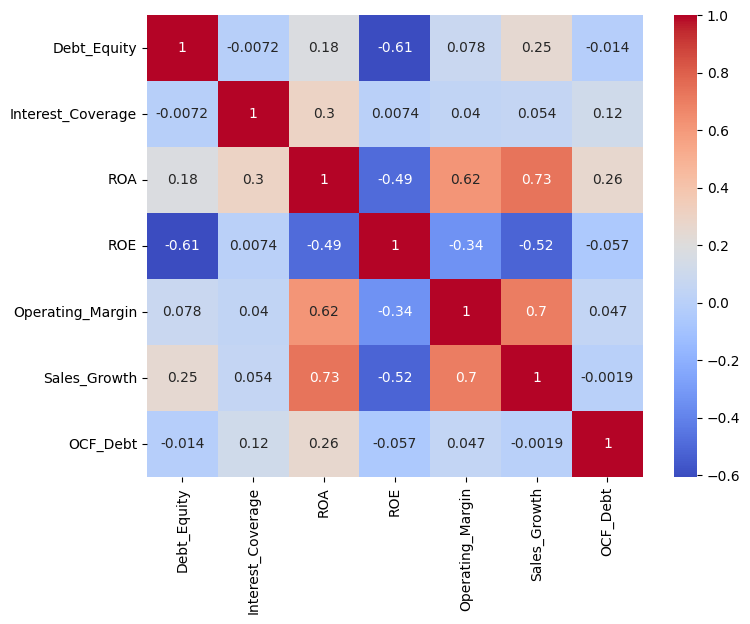

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(),annot=True,cmap='coolwarm')
plt.show()

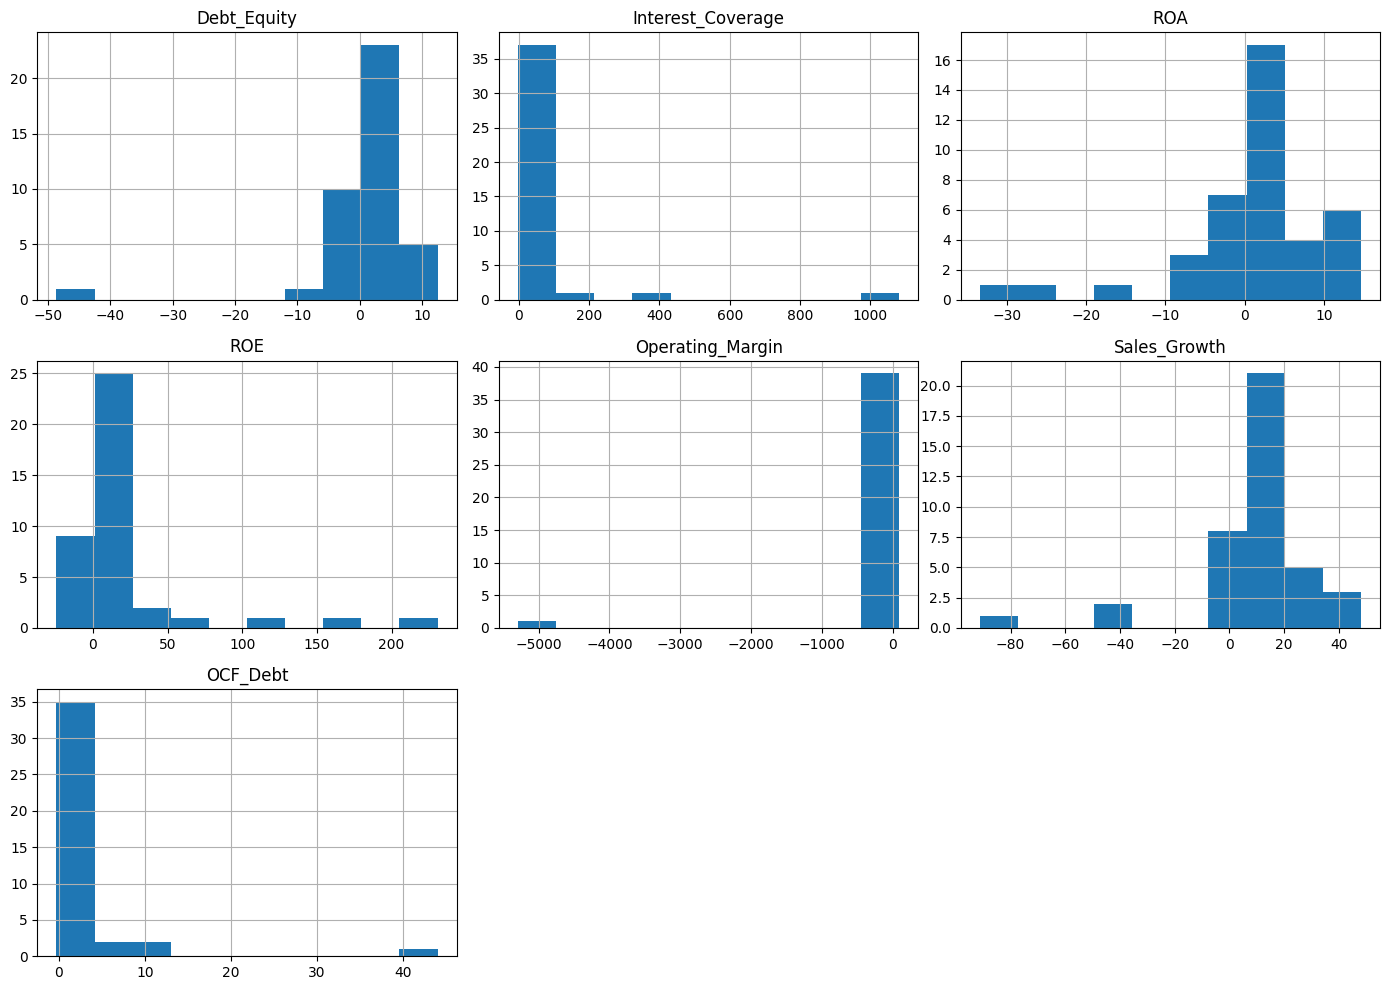

In [ ]:
df[features].hist(figsize=(14,10))

plt.tight_layout()
plt.show()

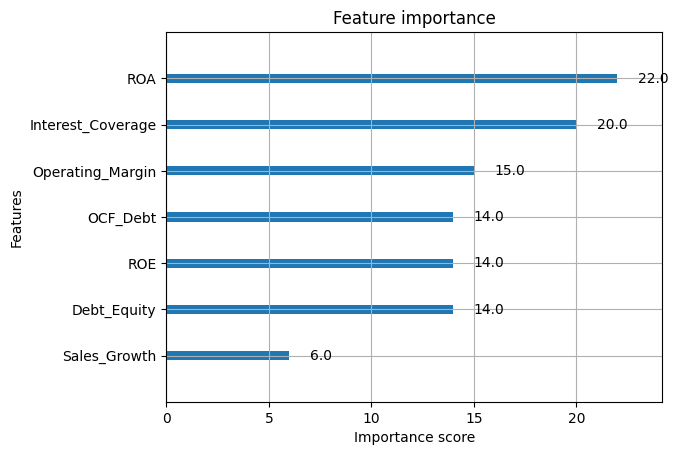

In [ ]:
xgb.plot_importance(model_full)

plt.show()

In [ ]:
from sklearn.metrics import roc_curve

# Logistic Regression ROC points
fpr_lr, tpr_lr, _ = roc_curve(y, lr_probs)

# XGBoost ROC points
fpr_xgb, tpr_xgb, _ = roc_curve(y, xgb_probs)

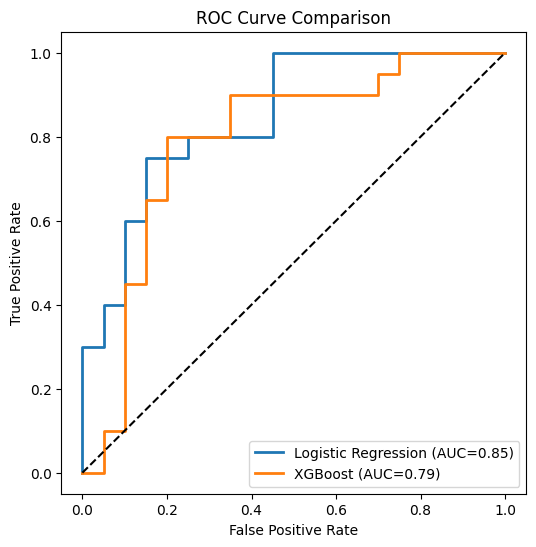

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr,
         label=f'Logistic Regression (AUC={roc_auc_score(y, lr_probs):.2f})',
         linewidth=2)

plt.plot(fpr_xgb, tpr_xgb,
         label=f'XGBoost (AUC={roc_auc_score(y, xgb_probs):.2f})',
         linewidth=2)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y, lr_preds))

print("XGBoost")
print(classification_report(y, xgb_preds))

Logistic Regression
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.76      0.80      0.78        20

    accuracy                           0.78        40
   macro avg       0.78      0.78      0.77        40
weighted avg       0.78      0.78      0.77        40

XGBoost
              precision    recall  f1-score   support

           0       0.78      0.70      0.74        20
           1       0.73      0.80      0.76        20

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40



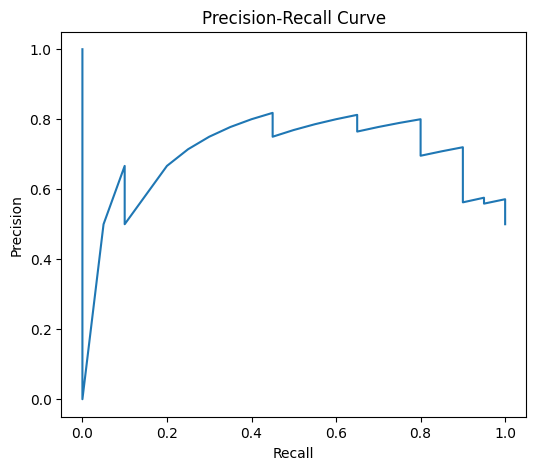

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y, xgb_probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model":["Logistic Regression","XGBoost"],
    "Accuracy":[accuracy_score(y,lr_preds),
                accuracy_score(y,xgb_preds)],
    "ROC AUC":[roc_auc_score(y,lr_probs),
               roc_auc_score(y,xgb_probs)]
})

results

,Model,Accuracy,ROC AUC
0,Logistic Regression,0.775,0.8500
1,XGBoost,0.750,0.7925


In [ ]:
import joblib

joblib.dump(model_full,
            "xgboost_credit_default_model.pkl")

['xgboost_credit_default_model.pkl']

In [ ]:
joblib.dump(scaler,
            "robust_scaler.pkl")

['robust_scaler.pkl']

In [ ]:
sample = df[features].iloc[[0]]

prediction = model_full.predict(sample)
probability = model_full.predict_proba(sample)

print(prediction)
print(probability)

[1]
[[0.22147429 0.7785257 ]]


In [ ]:
importance = pd.DataFrame({
    "Feature":features,
    "Importance":model_full.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2                ROA    0.297900
1  Interest_Coverage    0.224510
3                ROE    0.136267
6           OCF_Debt    0.095138
4   Operating_Margin    0.094126
5       Sales_Growth    0.076925
0        Debt_Equity    0.075133


In [ ]:
plt.savefig("roc_curve.png",dpi=300,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
df.to_csv("cleaned_corporate_default_prediction.csv", index=False)

In [ ]:
importance.to_csv("feature_importance.csv", index=False)

In [ ]:
results.to_csv("model_comparison.csv", index=False)

In [ ]:
misclassified = []

for pred, true, comp, prob in zip(xgb_preds, y, companies, xgb_probs):
    if pred != true:
        misclassified.append({
            "Company": comp,
            "Actual": true,
            "Predicted": pred,
            "Probability": prob
        })

misclassified = pd.DataFrame(misclassified)
misclassified.to_csv("misclassified_companies.csv", index=False)

misclassified

,Company,Actual,Predicted,Probability
0,Cox & Kings,1,0,0.428084
1,Gitanjali Gems,1,0,0.190727
2,Era Infra Engineering,1,0,0.435595
3,Talwalkars Better Value Fitness Ltd,1,0,0.186111
4,Thomas Cook India,0,1,0.741321
5,IndusInd Bank,0,1,0.652558
6,Bharti Airtel,0,1,0.811412
7,Thangamayil Jewellery Ltd.,0,1,0.524895
8,NCC Ltd,0,1,0.835390
9,Can Fin Homes,0,1,0.510295


In [ ]:
!ls

 cleaned_corporate_default_prediction.csv   robust_scaler.pkl
'Corporate Default Prediction.csv'	    roc_curve.png
 feature_importance.csv			    sample_data
 misclassified_companies.csv		    shap_summary.png
 model_comparison.csv			    xgboost_credit_default_model.pkl


In [ ]:
import shutil

shutil.make_archive(
    "Corporate_Default_Risk_Project",
    "zip",
    "."
)

'/content/Corporate_Default_Risk_Project.zip'

In [ ]:
from google.colab import files

files.download("Corporate_Default_Risk_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>